In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


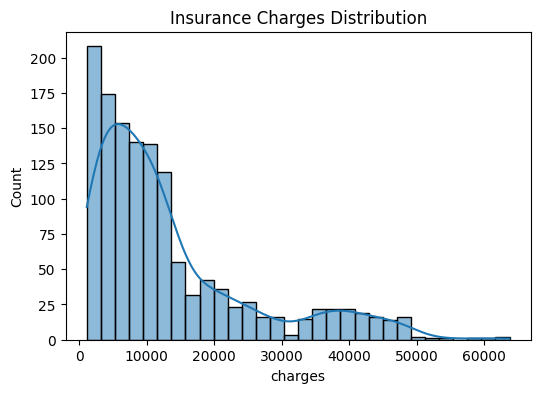

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df["charges"], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

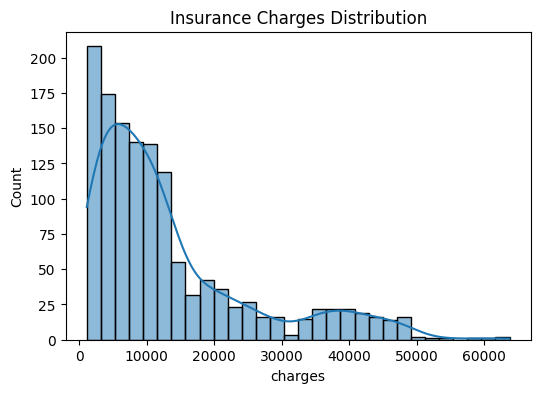

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["charges"], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

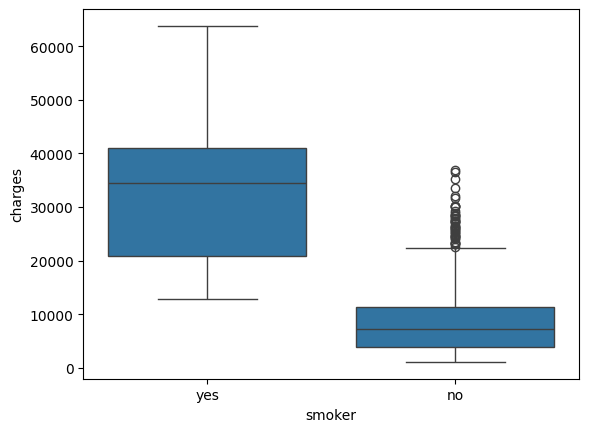

In [7]:
sns.boxplot(x="smoker", y="charges", data=df)
plt.show()

In [8]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [9]:
cat_cols = ["sex","smoker","region"]
num_cols = ["age","bmi","children"]

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [14]:
from sklearn.metrics import r2_score

y_pred = pipe.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8644399925086196


In [15]:
import joblib

joblib.dump(pipe,"insurance_model.pkl")

['insurance_model.pkl']